In [9]:
import kagglehub
path = kagglehub.competition_download('ieee-fraud-detection')

In [10]:
import pandas as pd

train_transaction = pd.read_csv(f'{path}/train_transaction.csv', index_col='TransactionID')
train_identity = pd.read_csv(f'{path}/train_identity.csv', index_col='TransactionID')

train = train_transaction.join(train_identity, how='left')

print(train_transaction.shape, train_identity.shape, train.shape)
train.head()

(590540, 393) (144233, 40) (590540, 433)


,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Nodes: 500, Edges: 76702


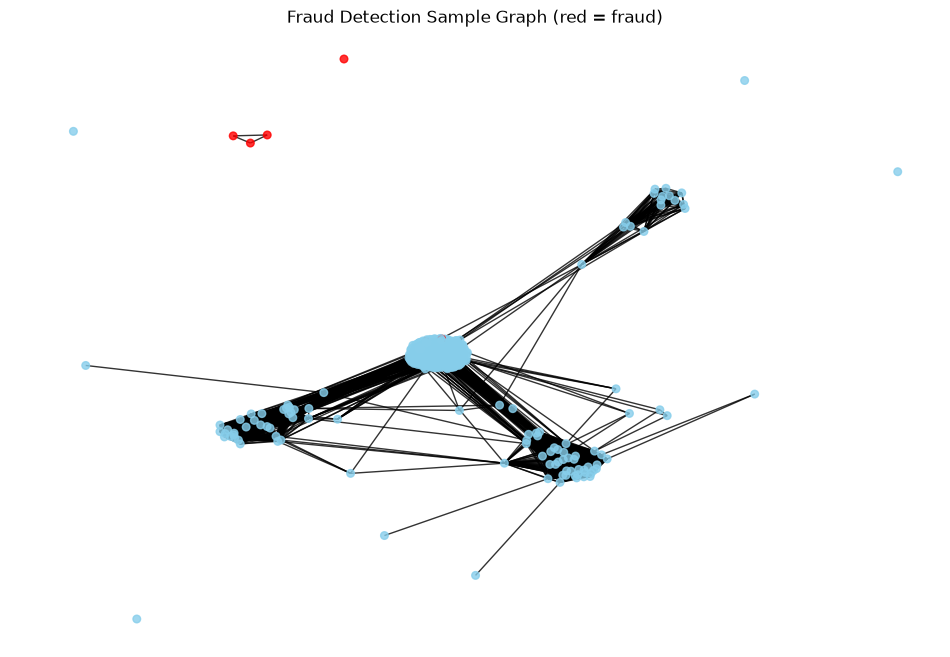

Zoomed subgraph: 492 nodes, 76699 edges


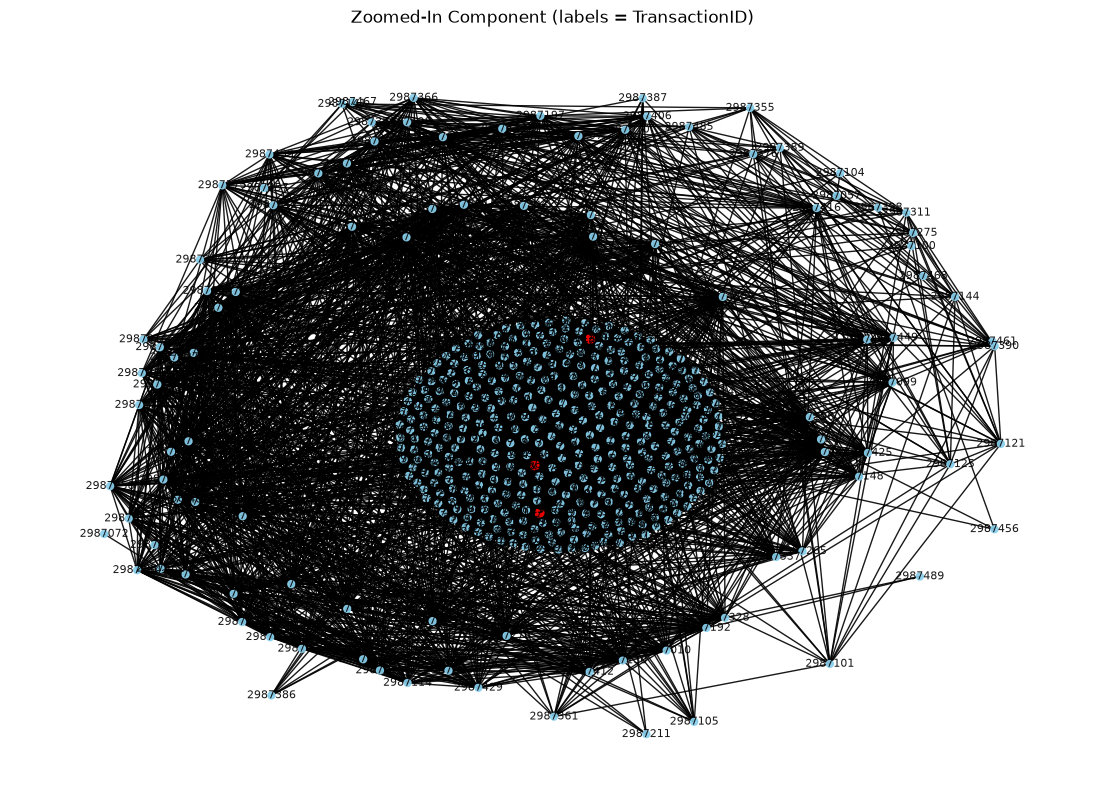

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# Build a sample graph: nodes = transactions, edges = shared card1 / device
sample = train.head(500).copy()
sample['DeviceInfo'] = sample['DeviceInfo'].fillna('unknown')

G = nx.Graph()
for tid, row in sample.iterrows():
    G.add_node(tid, isFraud=row['isFraud'], amount=row['TransactionAmt'])

cards, devices = {}, {}
for tid, row in sample.iterrows():
    cards.setdefault(row['card1'], []).append(tid)
    devices.setdefault(row['DeviceInfo'], []).append(tid)

for group in [cards, devices]:
    for tid_list in group.values():
        for i in range(len(tid_list)):
            for j in range(i + 1, len(tid_list)):
                G.add_edge(tid_list[i], tid_list[j])

print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')

colors = ['red' if d['isFraud'] else 'skyblue' for _, d in G.nodes(data=True)]
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw_networkx(G, pos, node_color=colors, node_size=30, with_labels=False, alpha=0.8)
plt.title('Fraud Detection Sample Graph (red = fraud)')
plt.axis('off')
plt.show()

# Zoom into a connected component (subgraph around a few transactions)
components = sorted(nx.connected_components(G), key=len, reverse=True)
zoom = G.subgraph(components[0])
print(f'Zoomed subgraph: {zoom.number_of_nodes()} nodes, {zoom.number_of_edges()} edges')

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(zoom, seed=7, k=1.2)
colors = ['red' if d['isFraud'] else 'skyblue' for _, d in zoom.nodes(data=True)]
sizes = [40 if d['isFraud'] else 25 for _, d in zoom.nodes(data=True)]
nx.draw_networkx(zoom, pos, node_color=colors, node_size=sizes, alpha=0.9, font_size=8)
plt.title('Zoomed-In Component (labels = TransactionID)')
plt.axis('off')
plt.show()

In [12]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import torch
import torch_geometric as pyg
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import average_precision_score, roc_auc_score
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)

# Sample a subset of transactions for the graph
n_sample = 6000
sample = train.sample(n_sample, random_state=42).copy()
sample['DeviceInfo'] = sample['DeviceInfo'].fillna('unknown')

# Standardized numeric node features
feat_cols = (['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1']
             + [f'C{i}' for i in range(1, 15)])
feat_cols = [c for c in feat_cols if c in sample.columns]
X_feat = sample[feat_cols].apply(lambda s: s.fillna(s.median()))
mu, sd = X_feat.mean(), X_feat.std().replace(0, 1)
X_feat = (X_feat - mu) / sd
node_features = torch.tensor(X_feat.values, dtype=torch.float)
node_labels = torch.tensor(sample['isFraud'].values, dtype=torch.long)

# Edges: transactions sharing a card1 or a device (cap 8 neighbours per group)
edges = set()
for col in ['card1', 'DeviceInfo']:
    lookup = defaultdict(list)
    for i, tid in enumerate(sample.index):
        lookup[sample.loc[tid, col]].append(i)
    for lst in lookup.values():
        rng = np.random.default_rng(0)
        rng.shuffle(lst)
        for a in range(len(lst)):
            for b in lst[a + 1:a + 1 + 8]:
                edges.add((lst[a], b))

edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
print(f'Nodes: {len(sample)}, Edges: {len(edges)}, Features: {len(feat_cols)}')

data = Data(x=node_features, edge_index=edge_index, y=node_labels)
num_nodes = data.num_nodes
perm = torch.randperm(num_nodes)
n_tr, n_va = int(0.7 * num_nodes), int(0.85 * num_nodes)
mask = torch.zeros((num_nodes, 3), dtype=torch.bool)
mask[perm[:n_tr], 0] = True
mask[perm[n_tr:n_va], 1] = True
mask[perm[n_va:], 2] = True
data.train_mask, data.val_mask, data.test_mask = mask[:, 0], mask[:, 1], mask[:, 2]
print(f'Train/Val/Test: {int(mask[:,0].sum())}/{int(mask[:,1].sum())}/{int(mask[:,2].sum())}')

Nodes: 6000, Edges: 69074, Features: 22
Train/Val/Test: 4200/900/900


In [13]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden=64, out=32):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, out)
        self.classifier = torch.nn.Linear(out, 2)

    def embed(self, data):
        x = self.conv1(data.x, data.edge_index).relu()
        return self.conv2(x, data.edge_index)

    def forward(self, data):
        return self.classifier(self.embed(data))

model = GCN(node_features.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(80):
    model.train()
    opt.zero_grad()
    out = model(data)
    loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    opt.step()
    model.eval()
    with torch.no_grad():
        proba = torch.softmax(model(data), dim=1)[:, 1]
        va_auc = roc_auc_score(data.y[data.val_mask].numpy(), proba[data.val_mask].numpy())
    if epoch % 20 == 0:
        print(f'epoch {epoch} loss {loss.item():.4f} valAUC {va_auc:.4f}')

epoch 0 loss 0.7986 valAUC 0.5058
epoch 20 loss 0.4547 valAUC 0.3830
epoch 40 loss 0.2385 valAUC 0.3899
epoch 60 loss 0.1744 valAUC 0.4855


In [14]:
model.eval()
with torch.no_grad():
    proba = torch.softmax(model(data), dim=1)[:, 1].numpy()
    emb = model.embed(data).numpy()
te = data.test_mask.numpy()
print(f'GNN test  PR-AUC: {average_precision_score(data.y.numpy()[te], proba[te]):.4f}')
print(f'GNN test  ROC-AUC: {roc_auc_score(data.y.numpy()[te], proba[te]):.4f}')

GNN test  PR-AUC: 0.0322
GNN test  ROC-AUC: 0.5627


In [15]:
import xgboost as xgb

# Combine tabular features with GNN node embeddings
X_comb = np.hstack([X_feat.reset_index(drop=True).values, emb])
y_arr = data.y.numpy()

# Use the same held-out split as the GNN for an honest comparison
train_idx = (data.train_mask | data.val_mask).numpy()
test_idx = data.test_mask.numpy()
Xtr, ytr = X_comb[train_idx], y_arr[train_idx]
Xte, yte = X_comb[test_idx], y_arr[test_idx]

scale_pos_weight = (ytr == 0).sum() / (ytr == 1).sum()
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
}
dtrain = xgb.DMatrix(Xtr, label=ytr)
dtest = xgb.DMatrix(Xte, label=yte)
model_xgb = xgb.train(params, dtrain, num_boost_round=100)
pred = model_xgb.predict(dtest)
print(f'XGB (tabular + GNN emb)  PR-AUC: {average_precision_score(yte, pred):.4f}')
print(f'XGB (tabular + GNN emb)  ROC-AUC: {roc_auc_score(yte, pred):.4f}')

XGB (tabular + GNN emb)  PR-AUC: 0.2791
XGB (tabular + GNN emb)  ROC-AUC: 0.7157


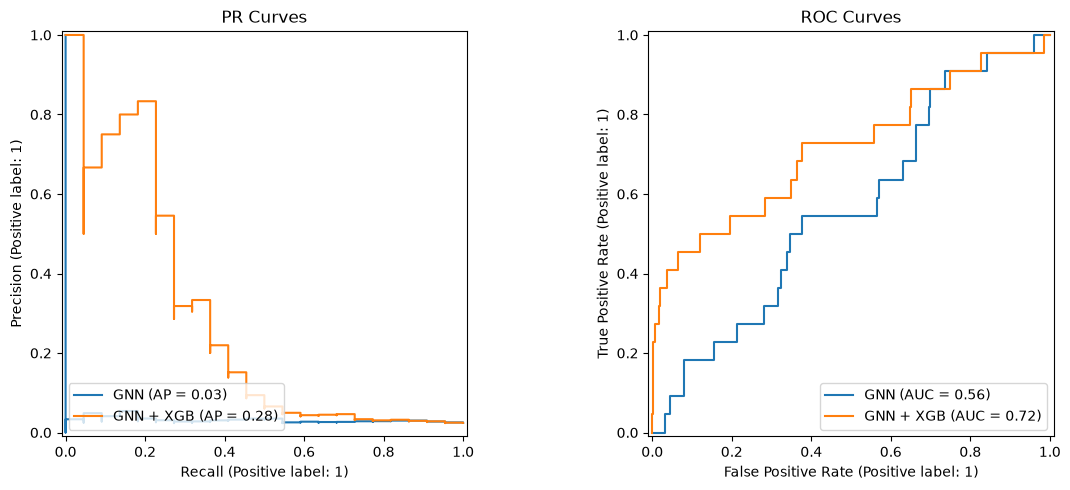

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
PrecisionRecallDisplay.from_predictions(data.y.numpy()[te], proba[te], ax=ax1, name='GNN')
PrecisionRecallDisplay.from_predictions(yte, pred, ax=ax1, name='GNN + XGB')
ax1.set_title('PR Curves')
RocCurveDisplay.from_predictions(data.y.numpy()[te], proba[te], ax=ax2, name='GNN')
RocCurveDisplay.from_predictions(yte, pred, ax=ax2, name='GNN + XGB')
ax2.set_title('ROC Curves')
plt.tight_layout()
plt.show()